#### Dataset
- Name: Titanic Dataset
- Task: Binary Classification
- Source: Kaggle
- Reference: Link: https://www.kaggle.com/c/titanic


<h1> Logistic Regression </h1>

**In this notebook, we first implement logistic regression manually—from scratch—and then compare it with a ready-made model from a library.**

Your learning path has progressed very well so far. Moving from Regression to Logistic Regression makes perfect sense, because

mathematically, Logistic Regression is closely related to the topics covered in the previous Regression section, yet it involves a major conceptual shift:

In Regression:

$$ y \in R $$

meaning the output is a continuous value.

However, in Classification:

$$ y \in \{0,1\} $$

the output is a discrete value.

### differences with LR:


| | Linear Regression | Logistic Regression |
| ---------- | ----------------- | ------------------- |
| Goal       | Predicting a value | Classification      |
| Output     | Real number       | Probability (0 to 1) |
| Activation | None              | Sigmoid             |
| Loss       | MSE               | Cross Entropy       |
| Problem Type | Regression        | Classification      |

### Goal:

To predict the probability of a sample belonging to a class using input features.

Why is linear regression unsuitable for classification?

Because the output could be values ​​like (-3.2, 0.7, 5.4).

However, a probability must satisfy:

$$ 0 \le p \le 1 $$

Therefore, we need to constrain the output.

This is where the sigmoid function comes in.

Why is it called "Regression" when it performs classification?

Because, historically speaking:

First, we have a regression model:

$$ z=w^Tx+b $$

Then, we convert it into a probability.

In other words:

$$ Regression + Sigmoid = Classification $$

### Sigmoid Function

Sigmoid function:

$$ \sigma(z)=\frac{1}{1+e^{-z}} $$

where:

$$ z=wX+b $$

Behavior:

If:

$$ z\rightarrow+\infty $$

then:

$$ \sigma(z)\rightarrow1 $$

If:

$$ z\rightarrow-\infty $$

then:

$$ \sigma(z)\rightarrow0 $$

Thus:

It converts any linear output into a probability.

### Loss Function

In regression:

We used:

$$ MSE $$

However, it is not suitable for classification,

because the output is a probability.

We use:

##### Binary Cross-Entropy (BCE)

Formula:

$$ J= -\frac1m \sum [ y\log(p) + (1-y)\log(1-p) ] $$

Where:

If the model is confident and correct → Low loss</br>
If the model is confident but incorrect → High loss

##### **The sigmoid function generates a probability; binary cross-entropy measures the quality of that probability; and gradient descent adjusts the weights to minimize the binary cross-entropy.**

### Gradient Descent

Interestingly, it is very similar to Linear Regression.

Gradient:

$$ dw= \frac1mX^T(p-y) $$

and:

$$ db= \frac1m\sum(p-y) $$

Update:

$$ w=w-\alpha dw $$ $$ b=b-\alpha db $$

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report

from src.logistic_regression import LogisticRegressionGD
from sklearn.linear_model import LogisticRegression

<h3> Step 1: Dataset

<h3> Step 1.1: Load The Dataset

Why do we use feature engineering?

Because we have already completed the following steps:

Extracting the title from the name</br>
Creating `FamilySize`</br>
Creating `FamilyCategory`</br>
Extracting the deck</br>
Calculating `FarePerPerson`

In machine learning, the process typically follows this flow:

Raw Data</br>
↓</br>
EDA</br>
↓</br>
Feature Engineering</br>
↓</br>
Model Training

We are currently at that final stage.

In [31]:
df = pd.read_csv(
    "../../../datasets/Titanic-Dataset/processed/titanic_feature_engineered.csv"
)

df.head()

,Survived,Age,Fare,FamilySize,FarePerPerson,SibSp,Parch,Sex,Embarked,FamilyCategory,Title,Deck
0,0,22.0,7.2500,2,3.62500,1,0,male,S,Small,Mr,Unknown
1,1,38.0,71.2833,2,35.64165,1,0,female,C,Small,Mrs,C
2,1,26.0,7.9250,1,7.92500,0,0,female,S,Alone,Miss,Unknown
3,1,35.0,53.1000,2,26.55000,1,0,female,S,Small,Mrs,C
4,0,35.0,8.0500,1,8.05000,0,0,male,S,Alone,Mr,Unknown


<h3> Step 1.2: Dataset Analysis

In [32]:
df.shape

(891, 12)

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Survived        891 non-null    int64  
 1   Age             714 non-null    float64
 2   Fare            891 non-null    float64
 3   FamilySize      891 non-null    int64  
 4   FarePerPerson   891 non-null    float64
 5   SibSp           891 non-null    int64  
 6   Parch           891 non-null    int64  
 7   Sex             891 non-null    object 
 8   Embarked        889 non-null    object 
 9   FamilyCategory  891 non-null    object 
 10  Title           891 non-null    object 
 11  Deck            891 non-null    object 
dtypes: float64(3), int64(4), object(5)
memory usage: 83.7+ KB


In [34]:
df.describe()

,Survived,Age,Fare,FamilySize,FarePerPerson,SibSp,Parch
count,891.000000,714.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,29.699118,32.204208,1.904602,19.916375,0.523008,0.381594
std,0.486592,14.526497,49.693429,1.613459,35.841257,1.102743,0.806057
min,0.000000,0.420000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,0.000000,20.125000,7.910400,1.000000,7.250000,0.000000,0.000000
50%,0.000000,28.000000,14.454200,1.000000,8.300000,0.000000,0.000000
75%,1.000000,38.000000,31.000000,2.000000,23.666667,1.000000,0.000000
max,1.000000,80.000000,512.329200,11.000000,512.329200,8.000000,6.000000


In [35]:
df.isnull().sum()

Survived            0
Age               177
Fare                0
FamilySize          0
FarePerPerson       0
SibSp               0
Parch               0
Sex                 0
Embarked            2
FamilyCategory      0
Title               0
Deck                0
dtype: int64

<h3> Step 1.3: Separate X and y

In [36]:
X = df.drop(
    "Survived",
    axis=1
)

y = df["Survived"]

In [37]:
print(X.shape)
print(y.shape)

(891, 11)
(891,)


<h3> Step 1.4: Identify Numerical and Categorical Features

In [38]:
numeric_features = X.select_dtypes(
    include=[
        "int64",
        "float64"
    ]
).columns.tolist()


categorical_features = X.select_dtypes(
    include=[
        "object"
    ]
).columns.tolist()


print(
    "Numerical Features:"
)

print(
    numeric_features
)

print(
    "\nCategorical Features:"
)

print(
    categorical_features
)

Numerical Features:
['Age', 'Fare', 'FamilySize', 'FarePerPerson', 'SibSp', 'Parch']

Categorical Features:
['Sex', 'Embarked', 'FamilyCategory', 'Title', 'Deck']


In feature engineering, we only created features:

Such as:

FamilySize</br>
Title</br>
Deck</br>
FarePerPerson

However, we did not handle missing values.

<h3> Step 1.5: Train Test Split

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


print(
    X_train.shape
)

print(
    X_test.shape
)

(712, 11)
(179, 11)


<h3> Step 1.6: Pipelines

In [40]:
numeric_transformer = Pipeline(
    steps=[
        
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),

        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [41]:
categorical_transformer = Pipeline(
    steps=[

        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),

        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

ColumnTransformer determines the output format based on the conditions:

If the result is largely sparse → sparse matrix</br>
If it is dense → NumPy array

In this case, because:

StandardScaler

and OneHotEncoder have been combined, the output is dense.

In [42]:
preprocessor = ColumnTransformer(
    transformers=[

        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

<h3> Step 1.7: fit on Train + transform

In [43]:
X_train_processed = preprocessor.fit_transform(
    X_train
)

X_test_processed = preprocessor.transform(
    X_test
)

In [44]:
print(
    X_train_processed.shape
)

print(
    X_test_processed.shape
)

(712, 28)
(179, 28)


In [45]:
print(
    type(X_train_processed)
)

X_train_processed

<class 'numpy.ndarray'>


array([[-0.08113533,  0.5138115 , -0.55633858, ...,  0.        ,
         0.        ,  1.        ],
       [-0.08113533, -0.66256323, -0.55633858, ...,  0.        ,
         0.        ,  1.        ],
       [-0.08113533,  3.95539858, -0.55633858, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 1.41700669,  0.0532047 ,  1.96266345, ...,  0.        ,
         0.        ,  1.        ],
       [ 1.34017889,  0.13909685, -0.55633858, ...,  0.        ,
         0.        ,  0.        ],
       [-0.08113533, -0.10973011, -0.55633858, ...,  0.        ,
         0.        ,  1.        ]])

In [46]:
print(
    X_train_processed.shape[1]
)

28


In [47]:
print(
    np.isnan(
        X_train_processed
    ).sum()
)

0


<h3> Step 2: Model building

In [48]:
model = LogisticRegressionGD(
    learning_rate=0.01,
    epochs=5000
)

In [49]:
model.fit(
    X_train_processed,
    y_train.values
)

In [50]:
print(
    model.weights.shape
)

print(
    model.bias
)

(28,)
0.2691103741569265


In [51]:
print("model.loss_history[:5]", model.loss_history[:5])
print("model.loss_history[-5:]", model.loss_history[-5:])

model.loss_history[:5] [0.6931471805599435, 0.691181707804628, 0.6892445591246077, 0.6873352412437518, 0.6854532686650153]
model.loss_history[-5:] [0.41673018881190904, 0.4167272567987558, 0.4167243255305612, 0.41672139500703675, 0.4167184652278944]


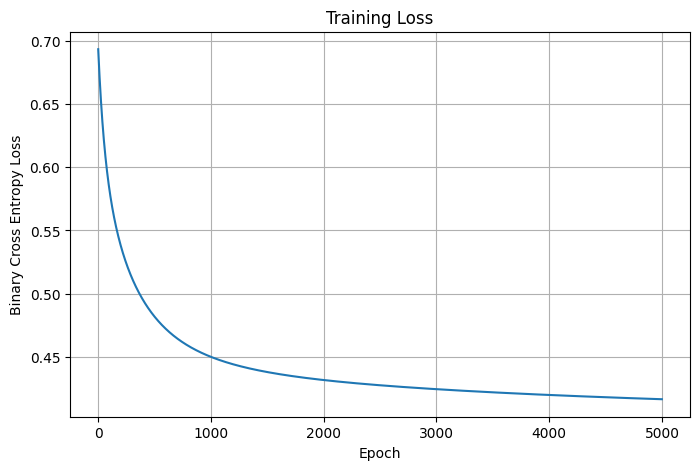

In [52]:
plt.figure(
    figsize=(8,5)
)

plt.plot(
    model.loss_history
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Binary Cross Entropy Loss"
)

plt.title(
    "Training Loss"
)

plt.grid()
plt.show()

This output means the model has successfully learned the pattern present in the data.

Prediction

In [53]:
y_prob = model.predict_proba(
    X_test_processed
)

y_prob[:5]

array([0.11929051, 0.11807256, 0.16428302, 0.07974302, 0.7268163 ])

In [54]:
y_pred = model.predict(
    X_test_processed
)

y_pred[:5]

array([0, 0, 0, 0, 1])

<h3> Step 3: Evaluation

Unlike regression, classification involves more than just a single metric.

There are several important metrics:

Accuracy</br>
Confusion </br>
Precision</br>
Recall</br>
F1-score

#### 3.1) Accuracy

The simplest metric:

$$ Accuracy= \frac{Correct Predictions}{Total Predictions} $$

In other words:

The proportion of total samples that were correctly predicted.

In [55]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "Accuracy:",
    accuracy
)

Accuracy: 0.8268156424581006


But why isn't accuracy enough?

In the Titanic case:

The classes are imbalanced.

Approximately:

Not Survived = 549

Survived = 342

If a model always predicts:

0

It still:

Achieves about 61% accuracy.

Yet, in reality, it hasn't learned anything.

So, we need to look at things in more detail.

#### 3.2) Confusion Matrix

1. True Negative (TN)
2. True Positive (TP)
3. False Positive (FP)
4. False Negative (FN)

In [56]:
cm = confusion_matrix(
    y_test,
    y_pred
)

cm

array([[98, 12],
       [19, 50]], dtype=int64)

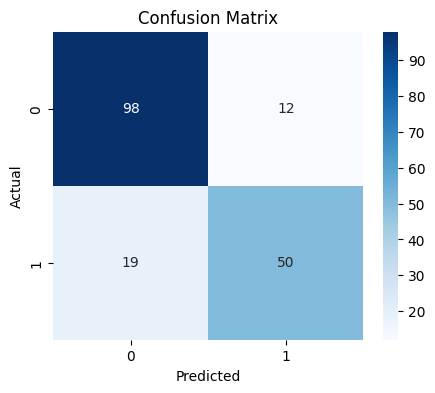

In [57]:
plt.figure(
    figsize=(5,4)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.title(
    "Confusion Matrix"
)

plt.show()

#### 3.3) Precision

$$ Precision= \frac{TP}{TP+FP} $$

Out of those who were predicted to survive, how many actually survived?

In [58]:
precision = precision_score(
    y_test,
    y_pred
)

print(
    "Precision:",
    precision
)

Precision: 0.8064516129032258


#### 3.4) Recall

$$ Recall= \frac{TP}{TP+FN} $$

Out of all those who actually survived, how many did we find?

In [59]:
recall = recall_score(
    y_test,
    y_pred
)

print(
    "Recall:",
    recall
)

Recall: 0.7246376811594203


#### 3.5) F1 Score

Combination of Precision and Recall:

$$ F1= 2 \frac{Precision \times Recall} {Precision+Recall} $$

In [60]:
f1 = f1_score(
    y_test,
    y_pred
)

print(
    "F1 Score:",
    f1
)

F1 Score: 0.7633587786259542


#### 3.6) Complete report (all-in-one)

In [61]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.84      0.89      0.86       110
           1       0.81      0.72      0.76        69

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.83      0.83      0.82       179



Comparison with Baseline

If the model simply predicted:

All = 0

The accuracy would be approximately:

$$ 549/891 = 61.6\% $$

Our model:

Achieved $$ 82.7\% $$

This means it has genuinely learned information from the features.

### Model Evaluation

The custom Logistic Regression model was evaluated using classification metrics.

The model achieved an accuracy of approximately 82.7%.

The confusion matrix showed:

- 98 true negatives
- 50 true positives
- 12 false positives
- 19 false negatives

The model performed better in identifying class 0 (not survived), achieving a recall of 0.89.

For the survival class, the model achieved a precision of 0.81 and recall of 0.72, indicating that while predictions of survival were usually correct, some true survivors were missed.

Overall, the model successfully learned meaningful patterns from the engineered Titanic features.

<h3> Step 4: Compare Custom Logistic Regression vs Scikit-Learn Logistic Regression

Building sklearn Model

In [63]:
sklearn_model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

Train

In [64]:
sklearn_model.fit(
    X_train_processed,
    y_train
)

LogisticRegression(max_iter=5000, random_state=42)

Prediction

In [65]:
y_pred_sklearn = sklearn_model.predict(
    X_test_processed
)

Evaluation

In [66]:
sklearn_accuracy = accuracy_score(
    y_test,
    y_pred_sklearn
)

sklearn_precision = precision_score(
    y_test,
    y_pred_sklearn
)

sklearn_recall = recall_score(
    y_test,
    y_pred_sklearn
)

sklearn_f1 = f1_score(
    y_test,
    y_pred_sklearn
)

Creating a comparison table

In [ ]:
comparison = pd.DataFrame(
    {
        "Model":[
            "Custom Logistic Regression",
            "Scikit-Learn Logistic Regression"
        ],

        "Accuracy":[
            accuracy,
            sklearn_accuracy
        ],

        "Precision":[
            precision,
            sklearn_precision
        ],

        "Recall":[
            recall,
            sklearn_recall
        ],

        "F1-score":[
            f1,
            sklearn_f1
        ]
    }
)

comparison

,Model,Accuracy,Precision,Recall,F1-score
0,Custom Logistic Regression,0.826816,0.806452,0.724638,0.763359
1,Scikit-Learn Logistic Regression,0.826816,0.787879,0.753623,0.770370


In [68]:
print(
    sklearn_model.coef_.shape
)

print(
    sklearn_model.intercept_
)

(1, 28)
[0.73778107]


They are not exactly the same because scikit-learn typically uses:

LBFGS (Limited-memory Broyden–Fletcher–Goldfarb–Shanno) </br>
Newton methods</br>
Default regularization

Whereas our model uses:

Simple Gradient Descent</br>
No regularization

Suppose we have a model:

$$ y=w^Tx+b $$

and a cost function:

$$ J(w) $$

We want to find the weights such that:

$$ \min J(w) $$

For example, in Logistic Regression:

$$ J(w)=BCE $$

Now, the question:

How do we find \(w\)?

There are several methods:

Gradient Descent</br>
Newton's Method</br>
L-BFGS</br>
Adam</br>
SGD

Difference between L-BFGS and Gradient Descent

| | Gradient Descent   | L-BFGS             |
| --------------------- | ------------------ | ------------------ |
| Type                  | First-order        | Quasi-second-order |
| Uses gradient         | Yes                  | Yes                  |
| Uses curvature        | No                  | Approximate        |
| Requires learning rate| Yes                | Usually no         |
| Memory                | Lower              | Slightly higher    |
| Convergence speed     | Moderate           | Usually faster     |
| Suitable for          | Very large data    | Medium-sized problems |

In general, therefore, L-BFGS is a quasi-Newton optimization algorithm that utilizes the history of weight and gradient changes to estimate second-order information—without calculating or storing the full Hessian—and is typically fast and stable for training models such as Logistic Regression.

### Comparison with Scikit-Learn

The custom Logistic Regression implementation was compared against Scikit-Learn's Logistic Regression.

Both models achieved the same accuracy (82.7%).

The custom implementation achieved slightly higher precision, while Scikit-Learn achieved slightly higher recall.

The similar performance confirms that the manually implemented Gradient Descent optimization correctly learned the classification boundary.

<h3> Step 5: Threshold Analysis

In [71]:
y_prob = model.predict_proba(
    X_test_processed
)

y_prob[:5]

array([0.11929051, 0.11807256, 0.16428302, 0.07974302, 0.7268163 ])

In [72]:
thresholds = [
    0.1,
    0.2,
    0.3,
    0.4,
    0.5,
    0.6,
    0.7,
    0.8,
    0.9
]

threshold_results = []

In [73]:
for threshold in thresholds:

    y_pred_threshold = (
        y_prob >= threshold
    ).astype(int)

    accuracy = accuracy_score(
        y_test,
        y_pred_threshold
    )

    precision = precision_score(
        y_test,
        y_pred_threshold
    )

    recall = recall_score(
        y_test,
        y_pred_threshold
    )

    f1 = f1_score(
        y_test,
        y_pred_threshold
    )

    threshold_results.append(
        [
            threshold,
            accuracy,
            precision,
            recall,
            f1
        ]
    )

In [74]:
threshold_df = pd.DataFrame(
    threshold_results,
    columns=[
        "Threshold",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ]
)

threshold_df

,Threshold,Accuracy,Precision,Recall,F1-score
0,0.1,0.446927,0.409639,0.985507,0.578723
1,0.2,0.759777,0.641304,0.855072,0.732919
2,0.3,0.793296,0.705128,0.797101,0.748299
3,0.4,0.832402,0.791045,0.768116,0.779412
4,0.5,0.826816,0.806452,0.724638,0.763359
5,0.6,0.810056,0.807018,0.666667,0.730159
6,0.7,0.759777,0.861111,0.449275,0.590476
7,0.8,0.692737,0.888889,0.231884,0.367816
8,0.9,0.664804,0.909091,0.144928,0.250000


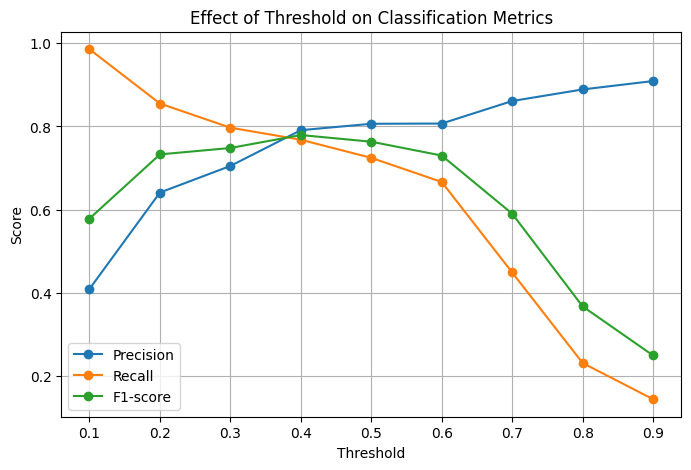

In [75]:
plt.figure(
    figsize=(8,5)
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1-score"],
    marker="o",
    label="F1-score"
)

plt.xlabel(
    "Threshold"
)

plt.ylabel(
    "Score"
)

plt.title(
    "Effect of Threshold on Classification Metrics"
)

plt.legend()
plt.grid()
plt.show()

### Threshold Analysis

Logistic Regression outputs probabilities rather than direct class labels.
A default threshold of 0.5 is commonly used, but it may not always provide the best balance between precision and recall.

Different decision thresholds were evaluated.

The results showed that reducing the threshold from 0.5 to 0.4 improved overall performance:

- Accuracy increased from 82.7% to 83.2%.
- Recall improved from 72.5% to 76.8%.
- F1-score improved from 76.3% to 77.9%.

Lower thresholds increase model sensitivity and recall, while higher thresholds improve precision at the cost of missing more positive samples.

Therefore, threshold selection should depend on the objective of the classification problem.